In [1]:
library(plyr)
library(dplyr)
library(tidyr)
library(lme4)
library(lmerTest)
library(interactions)
library(ggplot2)
library(emmeans)
library(rempsyc)
library(patchwork)


Attaching package: 'dplyr'


The following objects are masked from 'package:plyr':

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack



Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Suggested APA citation: Th<U+00E9>riault, R. (2023). rempsyc: Convenience functions for psychology. 
Journal of Open Source Software, 8(87), 5466. https://doi.org/10.21105/joss.05466



# TF measures predicted by acc * soc * age

## Load data

In [5]:
sort(colnames(tf_data))

[1] "ERN"                               "ERN_laplacian"                    
  [3] "ERN_min_CRN"                       "ERN_min_CRN_laplacian"            
  [5] "ICPS_early_DLPFC_L"                "ICPS_early_DLPFC_L_diff"          
  [7] "ICPS_early_DLPFC_R"                "ICPS_early_DLPFC_R_diff"          
  [9] "ICPS_early_DLPFC_collapsed"        "ICPS_early_DLPFC_diff_collapsed"  
 [11] "ICPS_early_MOTOR_L"                "ICPS_early_MOTOR_L_diff"          
 [13] "ICPS_early_MOTOR_R"                "ICPS_early_MOTOR_R_diff"          
 [15] "ICPS_early_MOTOR_collapsed"        "ICPS_early_MOTOR_diff_collapsed"  
 [17] "ICPS_early_OCC_L"                  "ICPS_early_OCC_L_diff"            
 [19] "ICPS_early_OCC_R"                  "ICPS_early_OCC_R_diff"            
 [21] "ICPS_early_OCC_collapsed"          "ICPS_early_OCC_diff_collapsed"    
 [23] "ICPS_late_DLPFC_L"                 "ICPS_late_DLPFC_L_diff"           
 [25] "ICPS_late_DLPFC_R"                 "ICPS_late_DLPFC_R_diff"           
 [27] "ICPS_late_DLPFC_collapsed"         "ICPS_late_DLPFC_diff_collapsed"   
 [29] "ICPS_late_MOTOR_L"                 "ICPS_late_MOTOR_L_diff"           
 [31] "ICPS_late_MOTOR_R"                 "ICPS_late_MOTOR_R_diff"           
 [33] "ICPS_late_MOTOR_collapsed"         "ICPS_late_MOTOR_diff_collapsed"   
 [35] "ICPS_late_OCC_L"                   "ICPS_late_OCC_L_diff"             
 [37] "ICPS_late_OCC_R"                   "ICPS_late_OCC_R_diff"             
 [39] "ICPS_late_OCC_collapsed"           "ICPS_late_OCC_diff_collapsed"     
 [41] "ITPS_early"                        "ITPS_early_diff"                  
 [43] "ITPS_late"                         "ITPS_late_diff"                   
 [45] "X6_or_more_err"                    "a"                                
 [47] "a_diff"                            "abq_scrdDis_s1_r1_e1"             
 [49] "abq_scrdEng_s1_r1_e1"              "abq_scrdTotal_s1_r1_e1"           
 [51] "acc"                               "acc_con"                          
 [53] "acc_incon"                         "accuracy_score"                   
 [55] "adexi_b_scrdInh_s1_r1_e1"          "adexi_b_scrdTotal_s1_r1_e1"       
 [57] "adexi_b_scrdWm_s1_r1_e1"           "age_m"                            
 [59] "ats_scrdCrit_s1_r1_e1"             "ats_scrdGen_s1_r1_e1"             
 [61] "ats_scrdStd_s1_r1_e1"              "ats_scrdTotal_s1_r1_e1"           
 [63] "bfne_b_parent_scrdTotal_s1_r1_e1"  "bfne_b_scrdTotal_s1_r1_e1"        
 [65] "bfnep_b_scrdTotal_s1_r1_e1"        "casi_scrdTotal_s1_r1_e1"          
 [67] "dersp_scrdAtt_s1_r1_e1"            "dersp_scrdCat_s1_r1_e1"           
 [69] "dersp_scrdDis_s1_r1_e1"            "dersp_scrdNeg_s1_r1_e1"           
 [71] "dp_inperson"                       "dyada_i1_s1_r1_e1"                
 [73] "dyadb_i1_s1_r1_e1"                 "dyadb_i2_s1_r1_e1"                
 [75] "dyadb_i3_s1_r1_e1"                 "dyadb_i4_s1_r1_e1"                
 [77] "dyadb_i5_s1_r1_e1"                 "dyadb_i6_s1_r1_e1"                
 [79] "dyadb_i7_s1_r1_e1"                 "dyadb_i8_s1_r1_e1"                
 [81] "dyadb_i9_s1_r1_e1"                 "eatq_scrdAC_s1_r1_e1"             
 [83] "eatq_scrdAff_s1_r1_e1"             "eatq_scrdAgg_s1_r1_e1"            
 [85] "eatq_scrdAtt_s1_r1_e1"             "eatq_scrdDM_s1_r1_e1"             
 [87] "eatq_scrdFear_s1_r1_e1"            "eatq_scrdFrus_s1_r1_e1"           
 [89] "edshvsc_scrdEdsChron_s1_r1_e1"     "edshvsc_scrdEdsEver_s1_r1_e1"     
 [91] "edshvsc_scrdEdsFreq_s1_r1_e1"      "edshvsc_scrdHvsEver_s1_r1_e1"     
 [93] "edshvsc_scrdHvsFreq_s1_r1_e1"      "edshvsp_scrdEdsChron_s1_r1_e1"    
 [95] "edshvsp_scrdEdsEver_s1_r1_e1"      "edshvsp_scrdEdsFreq_s1_r1_e1"     
 [97] "edshvsp_scrdHvsEver_s1_r1_e1"      "edshvsp_scrdHvsFreq_s1_r1_e1"     
 [99] "epepq15_scrdCI_s1_r1_e1"           "epepq15_scrdNS_s1_r1_e1"          
[101] "epepq15_scrdTP_s1_r1_e1"           "epepq15_scrdTotal_s1_r1_e1"       
[103] "erq_scrdCogRea_s1

In [2]:
rm(list = ls())
session = "s1_r1"
analysis_path = "/home/data/NDClab/analyses/thrive-theta-ddm/"
source(sprintf("%s/code/statistics/lmer_export_apa.R", analysis_path))
source(sprintf("%s/code/statistics/find_newest_file.R", analysis_path))
pic_path <- "/Users/fzaki001/thrive-theta-ddm/results/figures/ms"
tf_data <- read.csv(find_newest_file(sprintf("%s/derivatives/csv/%s/thrive*long*.csv", analysis_path, session)))
table_output_path = sprintf("%s/derivatives/statistics/full_sample/bfne/", analysis_path)
if (!dir.exists(table_output_path)) {
  dir.create(table_output_path, recursive = TRUE)
}
id_cols <- c('sub', 'age_m', 'sex', 'acc', 'soc', 'dp_inperson', 'first_soc')
data_cols <- c(
    'power_early',
    'ITPS_early',
    'ICPS_early_DLPFC_collapsed',
    'ICPS_early_MOTOR_collapsed',
    'ICPS_early_OCC_collapsed',
    'bfne_b_scrdTotal_s1_r1_e1'
)

tf_data <- tf_data[, c(id_cols, data_cols)]
tf_data <- tf_data %>%
  filter(!if_all(c(data_cols), is.na))

tf_data$soc <- as.factor(tf_data$soc)
tf_data$sub <- as.factor(tf_data$sub)
tf_data$sex <- as.factor(tf_data$sex)
tf_data$acc <- as.factor(tf_data$acc)
tf_data$first_soc <- as.factor(tf_data$first_soc)
# tf_data$task_num <- as.factor(tf_data$task_num)
tf_data$dp_inperson <- as.factor(tf_data$dp_inperson)

tf_data[c("age_m", data_cols)] <- as.data.frame(scale(tf_data[c("age_m", data_cols)]))

tf_data$soc <- revalue(tf_data$soc, c("0" = "NS", "1" = "S"))
tf_data$sex <- revalue(tf_data$sex, c("1" = "M", "2" = "F"))
tf_data$acc <- revalue(tf_data$acc, c("0" = "Error", "1" = "Correct"))

contrasts(tf_data$soc) <- rev(contr.sum(2))
contrasts(tf_data$acc) <- rev(contr.sum(2))
contrasts(tf_data$first_soc) <- rev(contr.sum(2))
contrasts(tf_data$sex) <- rev(contr.sum(2))
# contrasts(tf_data$task_num) <- rev(contr.sum(2))
contrasts(tf_data$dp_inperson) <- rev(contr.sum(2))


# outcome <- "Reaction"
# predictors <- "acc * age_m * soc + sex + dp_inperson + (1 | sub)"

# # Create the string formula
# full_formula_string <- paste(outcome, "~", predictors)
# formula <- as.formula(full_formula_string)
# Convert and run
# model <- lmer(as.formula(full_formula_string), data = sleepstudy)

[1] "The newest file is: /home/data/NDClab/analyses/thrive-theta-ddm//derivatives/csv/s1_r1/thrive_long_s1_r1_22_02_2026_23_31_39.csv"


Warning message:
"There was 1 warning in `filter()`.
i In argument: `!if_all(c(data_cols), is.na)`.
Caused by warning:
! Using an external vector in selections was deprecated in tidyselect 1.1.0.
i Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(data_cols)

  # Now:
  data %>% select(all_of(data_cols))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>."


In [5]:
# 1. Define the dependent variables you want to iterate over
outcomes <- c(
  "power_early", 
  "ITPS_early", 
  "ICPS_early_DLPFC_collapsed", 
  "ICPS_early_MOTOR_collapsed", 
  "ICPS_early_OCC_collapsed"
)

# 2. Define the static right-hand side of your model formula
predictors <- "acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub)"

# 3. Initialize an empty list to store the fitted models
models_list <- list()

# 4. Iterate through each outcome
for (outcome in outcomes) {
  # Dynamically build the formula
  f <- as.formula(paste(outcome, "~", predictors))
  
  # Fit the linear mixed-effects model
  cat(sprintf("Fitting model for %s...\n", outcome))
  model <- lmer(f, data = tf_data)
  print(summary(model))
  
  # Store the model in the list using the outcome name as the key
  models_list[[outcome]] <- model
  
  # Automatically export the APA table
  label <- paste0(outcome, "_bfne")
  lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label), print_formula=TRUE, formula=f)
}

# ---------------------------------------------------------
# Accessing and Plotting the Models
# ---------------------------------------------------------
# You can now retrieve any specific model from the list by name:
# summary(models_list[["power_early"]])

# Generate your interaction plots by calling the list directly:
# interact_plot(models_list[["power_early"]],
#               pred = "acc",
#               modx = "bfne_b_scrdTotal_s1_r1_e1",
#               interval = 1,
#               dodge.width = 0.2,
#               y.label = "Power",
#               x.label = "BFNE") + theme(legend.position = "bottom")

Fitting model for power_early...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1606.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.6783 -0.5215 -0.0356  0.5385  3.7810 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1455   0.3815  
 Residual             0.2635   0.5133  
Number of obs: 843, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                1.063e-02  4.481e-02  2.227e+02
acc1                                      -7.286e-01  1.775e-02  6.084e+02
soc1                                       1.449e-02  1.807e-02  6.396e+02
age_m                                      1.663e-01  3.083e-02  2.237e+02
bfne_b_scrdTotal_s1_r1_e1                  7.779e-02  3.225e-02  2.238e+02
sex1                                      -1.412e-01  3.278e-02  2.241e


Correlation matrix not shown by default, as p = 18 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Fitting model for ITPS_early...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 2342

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6116 -0.5633 -0.0873  0.4877  3.7298 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.2224   0.4716  
 Residual             0.7141   0.8450  
Number of obs: 839, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.013563   0.062231 217.675873
acc1                                       -0.169043   0.029282 602.600666
soc1                                        0.007083   0.029686 640.981915
age_m                                       0.148874   0.042817 218.085859
bfne_b_scrdTotal_s1_r1_e1                   0.020661   0.044726 217.139993
sex1                                        0.084673   0.045553 218.965626


Correlation matrix not shown by default, as p = 18 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Fitting model for ICPS_early_DLPFC_collapsed...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 2138.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9492 -0.5281 -0.0585  0.4307  4.0191 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1770   0.4207  
 Residual             0.5696   0.7547  
Number of obs: 832, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.028984   0.055889 222.614498
acc1                                       -0.448547   0.026269 599.014871
soc1                                       -0.014295   0.026626 636.306168
age_m                                       0.203251   0.038386 221.332734
bfne_b_scrdTotal_s1_r1_e1                   0.053073   0.039971 217.935071
sex1                                        0.007254   0


Correlation matrix not shown by default, as p = 18 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Fitting model for ICPS_early_MOTOR_collapsed...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1992.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6423 -0.5127 -0.0301  0.4650  3.8457 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1554   0.3942  
 Residual             0.4672   0.6835  
Number of obs: 835, groups:  sub, 229

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.030554   0.051262 212.872531
acc1                                       -0.569765   0.023775 596.398182
soc1                                        0.009785   0.024099 632.468670
age_m                                       0.186203   0.035337 213.441412
bfne_b_scrdTotal_s1_r1_e1                   0.049470   0.036937 212.841711
sex1                                       -0.022552   0


Correlation matrix not shown by default, as p = 18 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Fitting model for ICPS_early_OCC_collapsed...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 2210

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7165 -0.5606  0.0095  0.4960  4.0454 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.2234   0.4726  
 Residual             0.6175   0.7858  
Number of obs: 827, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                 0.017564   0.060355 214.397406
acc1                                       -0.393296   0.027504 594.240954
soc1                                        0.005247   0.027893 628.609087
age_m                                       0.058412   0.041736 218.168948
bfne_b_scrdTotal_s1_r1_e1                   0.041285   0.043694 218.996899
sex1                                       -0.079701   0.044


Correlation matrix not shown by default, as p = 18 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



In [25]:
model <- lmer(ICPS_early_DLPFC_collapsed ~ acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + 	sex + dp_inperson + (1 | sub), data = tf_data)
print(summary(model))

# model <- lmer(ITPS_early ~ acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + 	sex + dp_inperson + (1 | sub), data = tf_data)
# print(summary(model))

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
ICPS_early_DLPFC_collapsed ~ acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 2138.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9492 -0.5281 -0.0585  0.4307  4.0191 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1770   0.4207  
 Residual             0.5696   0.7547  
Number of obs: 832, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.028984   0.055889 222.614498
acc1                                       -0.448547   0.026269 599.014871
soc1                                       -0.014295   0.026626 636.306168
age_m                                       0.203251   0.038386 221.332734
bfne_b_scrdTotal_s1_r1_e1                   0.053073   0.039971 217


Correlation matrix not shown by default, as p = 18 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it




In [10]:
options(shiny.fullstacktrace = TRUE) # Optional debugging
options(device = function() {
  ragg::agg_png(res = 300, width = 7, height = 5, units = "in")
})

x Detected factor predictor.
i Plotting with cat_plot() instead.
i See `?interactions::cat_plot()` for full details on how to specify models
  with categorical predictors.
i If you experience errors or unexpected results, try using cat_plot()
  directly.


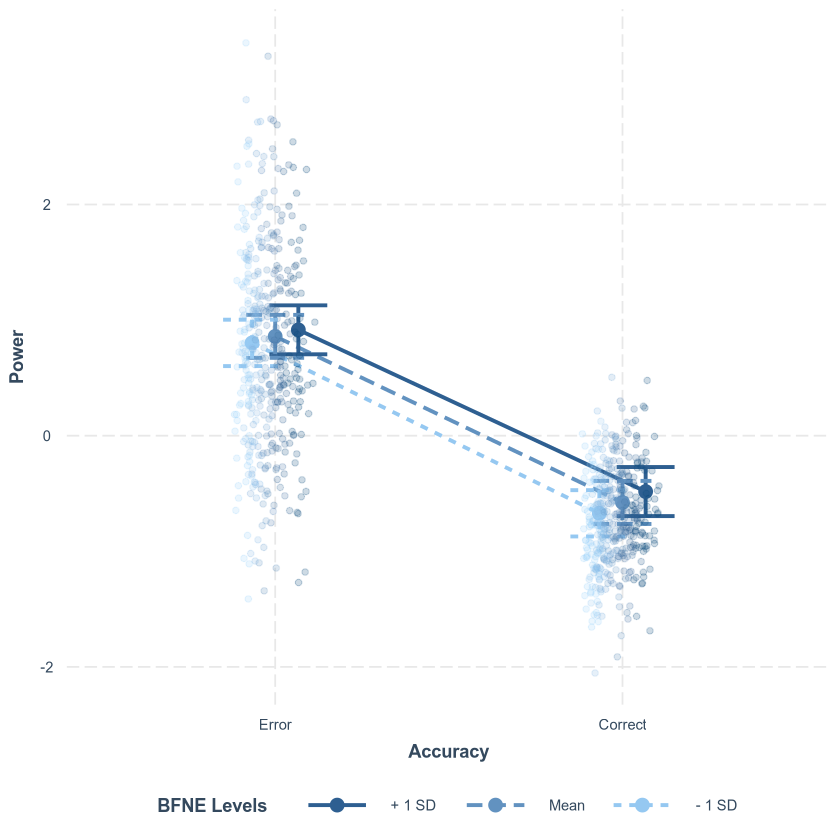

In [11]:
# interact_plot(model,
#               pred = "acc",
#               modx="bfne_b_scrdTotal_s1_r1_e1",
#               interval = 1,
#               dodge.width = 0.2,
#               y.label = "Power",
#               x.label = "BFNE",
#              ) + theme(legend.position = "bottom")


interact_plot(model, 
              pred = "acc", 
              modx = "bfne_b_scrdTotal_s1_r1_e1",
              interval = TRUE,           # Enables confidence intervals
              int.type = "confidence",   # Explicitly set to CI
              plot.points = TRUE,        # Adds raw data for transparency
              point.alpha = 0.2,         # Reduces noise from overlapping points
              jitter = 0.1,              # Prevents point stacking
              line.thickness = 1.1,
              dodge.width = 0.2,
              x.label = "Accuracy", 
              y.label = "Power",
              legend.main = "BFNE Levels",
             ) +                      # High-contrast publication theme
  theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    strip.background = element_blank()
  )

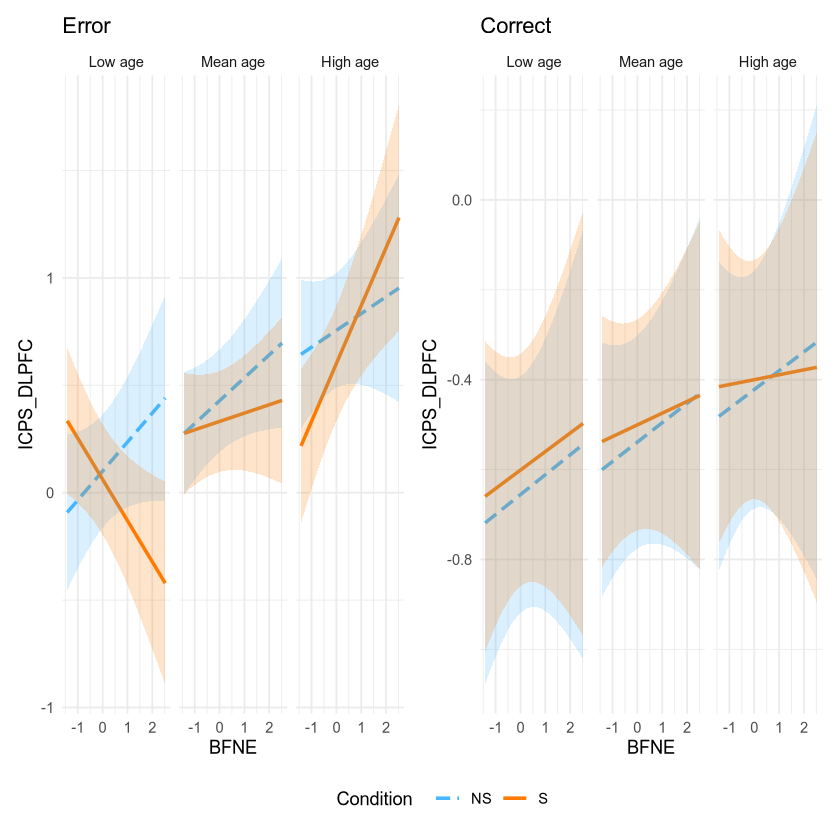

In [26]:
library(interactions)
library(ggplot2)
library(patchwork) # Required for the + operator and plot_layout

# 1. Define labels for Age (mod2)
my_labels <- c("Low age", "Mean age", "High age")

# --- Plot for Error ---
p1 <- interact_plot(
  model,
  pred = "bfne_b_scrdTotal_s1_r1_e1",
  modx = "soc",
  mod2 = "age_m",
  mod2.labels = my_labels,
    y.label = "ICPS_DLPFC",
    x.label = "BFNE",
  legend.main = "Condition",            # Renames the legend title to BFNE
  at = list(acc = "Error"),
  interval = TRUE
) +
  ggtitle("Error") +
  theme_minimal() +
  theme(legend.position = "none")   # Hide legend on first plot to avoid clutter

# --- Plot for Correct ---
p2 <- interact_plot(
  model,
  pred = "bfne_b_scrdTotal_s1_r1_e1",
  modx = "soc",
  mod2 = "age_m",
  mod2.labels = my_labels,
    y.label = "ICPS_DLPFC",
    x.label = "BFNE",
  legend.main = "Condition",            # Renames the legend title to BFNE
  at = list(acc = "Correct"),
  interval = TRUE
) +
  ggtitle("Correct") +
  theme_minimal()

# --- Combine and Display ---
combined_plot <- p1 + p2 + 
  plot_layout(guides = "collect") & 
  theme(legend.position = "bottom")

# Print to the Plots pane
print(combined_plot)


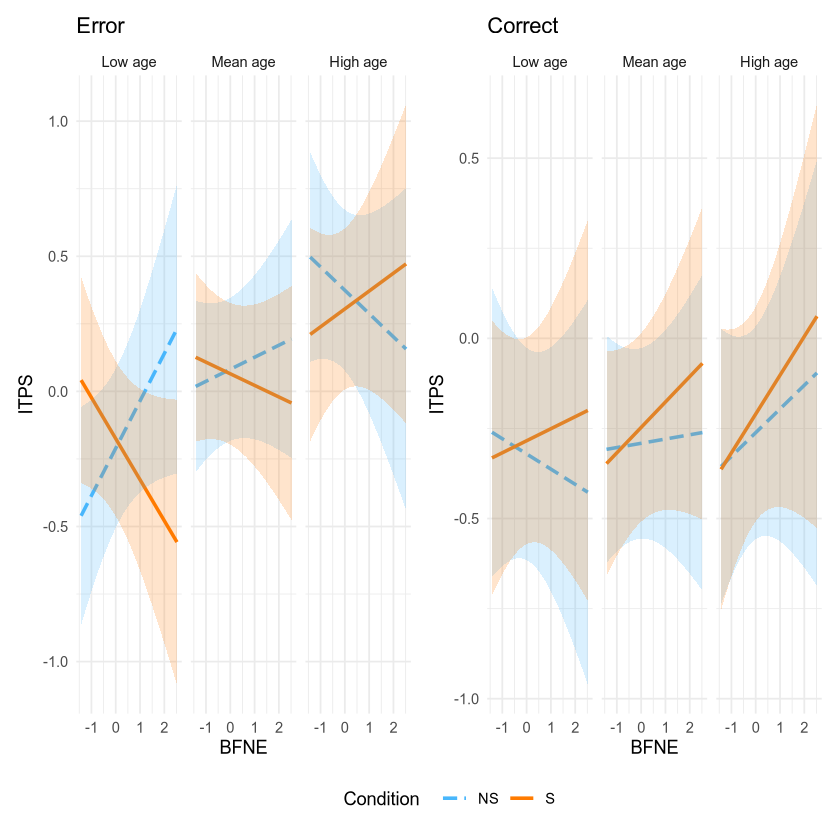

In [24]:
library(interactions)
library(ggplot2)
library(patchwork) # Required for the + operator and plot_layout

# 1. Define labels for Age (mod2)

model <- lmer(ICPS_early_DLPFC_collapsed ~ acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + 	sex + dp_inperson + (1 | sub), data = tf_data)
print(summary(model))
my_labels <- c("Low age", "Mean age", "High age")

# --- Plot for Error ---
p1 <- interact_plot(
  model,
  pred = "bfne_b_scrdTotal_s1_r1_e1",
  modx = "soc",
  mod2 = "age_m",
  mod2.labels = my_labels,
    y.label = "ITPS",
    x.label = "BFNE",
  legend.main = "Condition",            # Renames the legend title to BFNE
  at = list(acc = "Error"),
  interval = TRUE
) +
  ggtitle("Error") +
  theme_minimal() +
  theme(legend.position = "none")   # Hide legend on first plot to avoid clutter

# --- Plot for Correct ---
p2 <- interact_plot(
  model,
  pred = "bfne_b_scrdTotal_s1_r1_e1",
  modx = "soc",
  mod2 = "age_m",
  mod2.labels = my_labels,
    y.label = "ITPS",
    x.label = "BFNE",
  legend.main = "Condition",            # Renames the legend title to BFNE
  at = list(acc = "Correct"),
  interval = TRUE
) +
  ggtitle("Correct") +
  theme_minimal()

# --- Combine and Display ---
combined_plot <- p1 + p2 + 
  plot_layout(guides = "collect") & 
  theme(legend.position = "bottom")

# Print to the Plots pane
print(combined_plot)


x Detected factor predictor.
i Plotting with cat_plot() instead.
i See `?interactions::cat_plot()` for full details on how to specify models
  with categorical predictors.
i If you experience errors or unexpected results, try using cat_plot()
  directly.


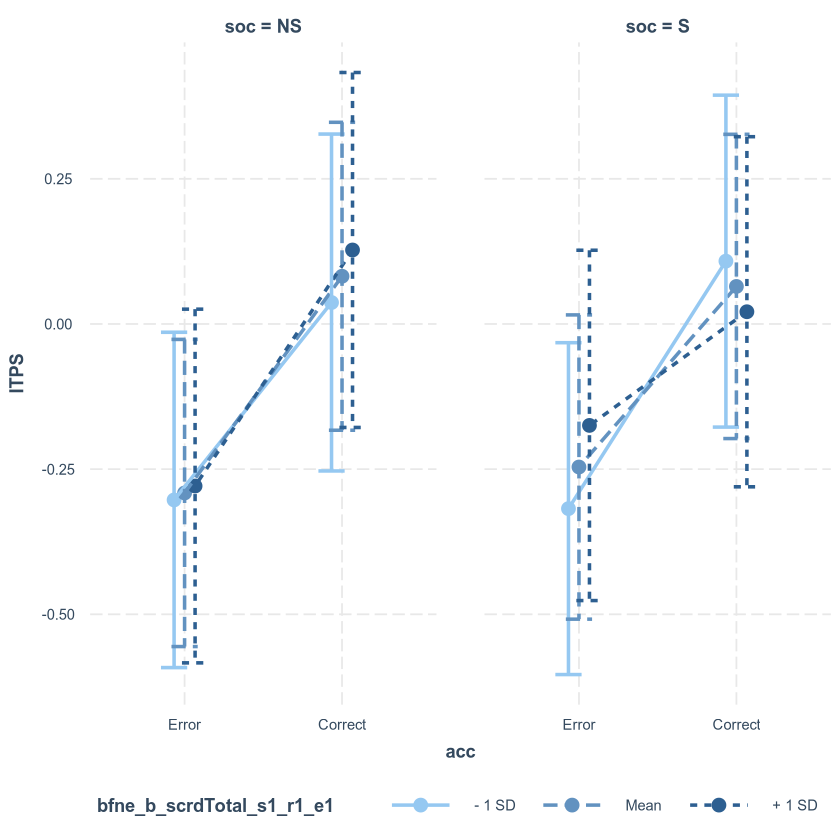

In [5]:
interact_plot(model,
              pred = "acc",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "ITPS",
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

In [5]:
# 1. Define the variables for clarity
# Replace "Level_A" and "Level_B" with your actual acc1 factor levels (e.g., 0 and 1)
# If acc1 is numeric, choose specific values like mean +/- SD

predictors <- "acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub)"
outcome =  "ICPS_early_DLPFC_collapsed"
f <- as.formula(paste(outcome, "~", predictors))
  
cat(sprintf("Fitting model for %s...\n", outcome))
model <- lmer(f, data = tf_data)


label = 'frontolateral'
my_labels <- c("Low age", "Mean age", "High age")
# --- Plot for Acc Level 1 ---
p1 <- interact_plot(
  model,
  pred = bfne_b_scrdTotal_s1_r1_e1,
  modx = soc,
  mod2 = age_m,
    x.label = "BFNE",
    y.label = "Midfrontal-Frontolateral ICPS",
    mod2.labels = my_labels,
    interval = TRUE,
  at = list(acc = "Error"),  # <--- ISOLATE ACC LEVEL HERE
  # plot.points = TRUE            # Optional: show raw data
) +
  ggtitle("Error") +
  theme_minimal()

# --- Plot for Acc Level 2 ---
p2 <- interact_plot(
  model,
  pred = bfne_b_scrdTotal_s1_r1_e1,
  modx = soc,
  mod2 = age_m,
    x.label = "BFNE",
    y.label = "Midfrontal-Frontolateral ICPS",
    mod2.labels = my_labels,
    interval = TRUE,
  at = list(acc = "Correct"),  # <--- ISOLATE ACC LEVEL HERE
  # plot.points = TRUE
) +
  ggtitle("Correct") +
  theme_minimal()

# --- Combine them ---
# This creates a side-by-side comparison
# p1 + p2

combined_plot <- p1 + p2 + 
  plot_layout(guides = "collect") # Optional: merges legends to save even more space

# Save with explicit width (in inches)
ggsave(sprintf("wide_interaction_plot_%s.png", label), combined_plot, width = 16, height = 6, dpi = 300)

In [26]:
# 1. Define the variables for clarity
# Replace "Level_A" and "Level_B" with your actual acc1 factor levels (e.g., 0 and 1)
# If acc1 is numeric, choose specific values like mean +/- SD
my_labels <- c("Low age", "Mean age", "High age")
# --- Plot for Acc Level 1 ---
p1 <- interact_plot(
  model,
  pred = bfne_b_scrdTotal_s1_r1_e1,
  modx = soc,
  mod2 = age_m,
    mod2.labels = my_labels,
  at = list(acc = "Error"),  # <--- ISOLATE ACC LEVEL HERE
  # plot.points = TRUE            # Optional: show raw data
) +
  ggtitle("Error") +
  theme_minimal()

# --- Plot for Acc Level 2 ---
p2 <- interact_plot(
  model,
  pred = bfne_b_scrdTotal_s1_r1_e1,
  modx = soc,
  mod2 = age_m,
    mod2.labels = my_labels,
  at = list(acc = "Correct"),  # <--- ISOLATE ACC LEVEL HERE
  # plot.points = TRUE
) +
  ggtitle("Correct") +
  theme_minimal()

# --- Combine them ---
# This creates a side-by-side comparison
# p1 + p2

combined_plot <- p1 + p2 + 
  plot_layout(guides = "collect") # Optional: merges legends to save even more space

# Save with explicit width (in inches)
ggsave(sprintf("wide_interaction_plot_%s.png", label), combined_plot, width = 16, height = 6, dpi = 300)

In [11]:
predictors <- "acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub)"
outcome =  "ICPS_early_OCC_collapsed"
f <- as.formula(paste(outcome, "~", predictors))
label = 'posterolateral'
cat(sprintf("Fitting model for %s...\n", outcome))
model <- lmer(f, data = tf_data)

p1 <- interact_plot(model,
              pred = "bfne_b_scrdTotal_s1_r1_e1",
              modx="age_m",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "Midfronftal-Posterolateral ICPS",
              x.label= "BFNE",
              legend.main = "Age"
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

ggsave(sprintf("interaction_plot_%s.png", label), p1, width = 16, height = 6, dpi = 300)

Fitting model for ICPS_early_OCC_collapsed...


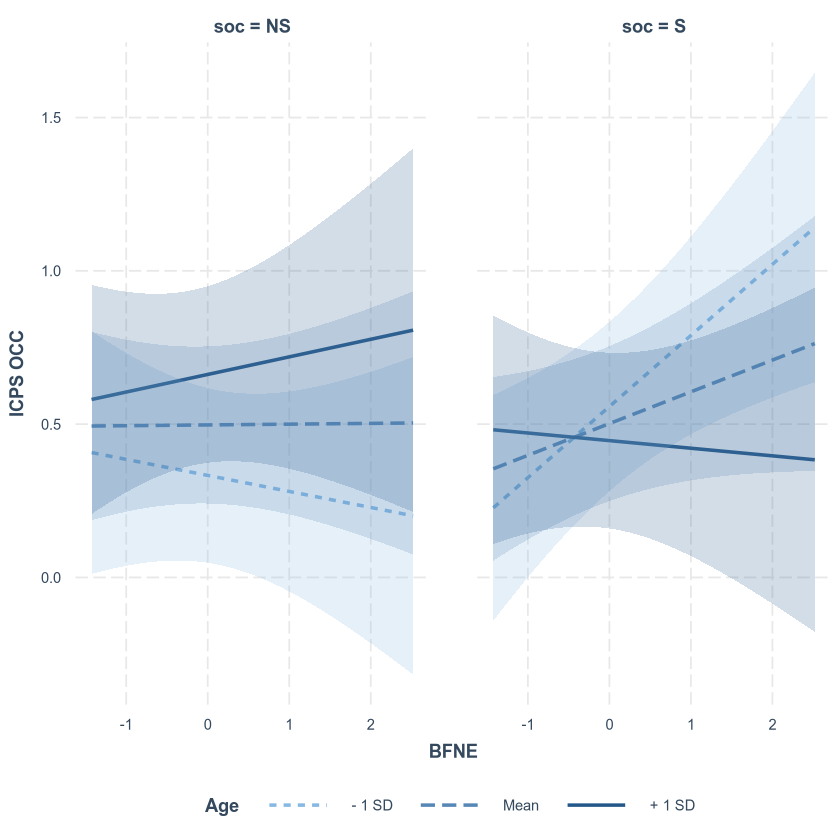

In [8]:
interact_plot(model,
              pred = "bfne_b_scrdTotal_s1_r1_e1",
              modx="age_m",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "ICPS OCC",
              x.label= "BFNE",
              legend.main = "Age"
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

In [9]:
summary(model)


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 2210

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7165 -0.5606  0.0095  0.4960  4.0454 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.2234   0.4726  
 Residual             0.6175   0.7858  
Number of obs: 827, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                 0.017564   0.060355 214.397406
acc1                                       -0.393296   0.027504 594.240954
soc1                                        0.005247   0.027893 628.609087
age_m                                       0.058412   0.041736 218.168948
bfne_b_scrdTotal_s1_r1_e1                   0.041285   0.043694 218.996899
sex1                                       -0.079701   0.044400 219.214273
dp_inperson1                   

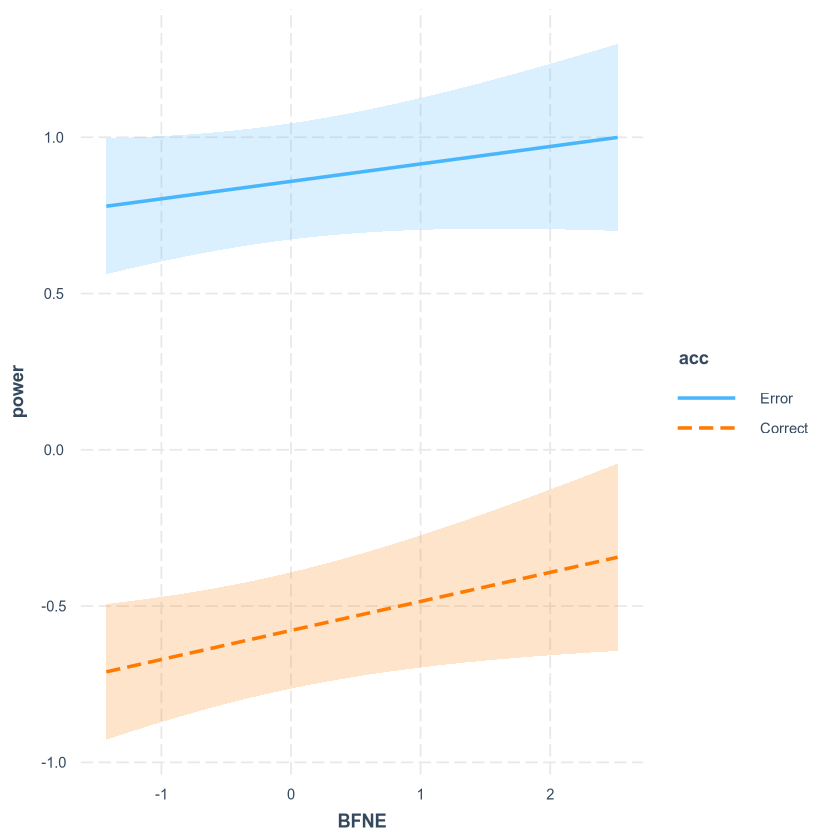

In [14]:
model <- lmer(power_early ~ acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub)
    , data = tf_data)

interact_plot(model,
              pred = "bfne_b_scrdTotal_s1_r1_e1",
              modx="acc",
              interval = TRUE,
              dodge.width = 0.2,
              y.label = "power",
              x.label = "BFNE",
             )

# DDM measures predicted by ICPS

## Load data

In [12]:
rm(list = ls())
session = "s1_r1"
analysis_path = "/home/data/NDClab/analyses/thrive-theta-ddm/"
source(sprintf("%s/code/statistics/lmer_export_apa.R", analysis_path))
source(sprintf("%s/code/statistics/find_newest_file.R", analysis_path))
pic_path <- "/Users/fzaki001/thrive-theta-ddm/results/figures/ms"
# tf_data <- read.csv("/Users/fzaki001/IDENTIFIABLE/tf_data_collapsed_merged.csv")
tf_data <- read.csv(find_newest_file(sprintf("%s/derivatives/csv/%s/thrive*long*.csv", analysis_path, session)))
table_output_path = sprintf("%s/derivatives/statistics/full_sample/bfne/", analysis_path)
if (!dir.exists(table_output_path)) {
  dir.create(table_output_path, recursive = TRUE)
}
# it doesnt matter 0 or 1 because the models below use difference scores; because of that we need to get rid of duplicates (diff scores are the same for acc=0 and acc=1)
id_cols <- c('sub', 'age_m', 'sex', 'acc', 'soc', 'dp_inperson', 'first_soc')
data_cols <- c(
    'reversed_ratio_diff',
    'a_diff',
    'p_diff',
    'ter_diff',
    'ICPS_early_DLPFC_diff_collapsed',
    'ICPS_early_MOTOR_diff_collapsed',
    'ICPS_early_OCC_diff_collapsed',
    'bfne_b_scrdTotal_s1_r1_e1'
)
tf_data <- tf_data[, c(id_cols, data_cols)]
tf_data <- tf_data %>%
  filter(!if_all(c(data_cols), is.na))
tf_data <- subset(tf_data, tf_data$acc == 1)

tf_data$sub <- as.factor(tf_data$sub)
tf_data$soc <- as.factor(tf_data$soc)
tf_data$sex <- as.factor(tf_data$sex)
tf_data$acc <- as.factor(tf_data$acc)
tf_data$first_soc <- as.factor(tf_data$first_soc)
# tf_data$task_num <- as.factor(tf_data$task_num)
tf_data$dp_inperson <- as.factor(tf_data$dp_inperson)

tf_data[c("age_m", data_cols)] <- as.data.frame(scale(tf_data[c("age_m", data_cols)]))

tf_data$soc <- revalue(tf_data$soc, c("0" = "NS", "1" = "S"))
tf_data$sex <- revalue(tf_data$sex, c("1" = "M", "2" = "F"))

# contrasts(tf_data$acc) <- rev(contr.sum(2))
contrasts(tf_data$sex) <- rev(contr.sum(2))
contrasts(tf_data$soc) <- rev(contr.sum(2))
contrasts(tf_data$first_soc) <- rev(contr.sum(2))
# contrasts(tf_data$task_num) <- rev(contr.sum(2))
contrasts(tf_data$dp_inperson) <- rev(contr.sum(2))

[1] "The newest file is: /home/data/NDClab/analyses/thrive-theta-ddm//derivatives/csv/s1_r1/thrive_long_s1_r1_22_02_2026_23_31_39.csv"


In [7]:
# 1. Define the dependent variables you want to iterate over
outcomes <- c(
    'reversed_ratio_diff',
    'a_diff'
)

# 2. Define the static right-hand side of your model formula
predictors <- "ICPS_early_DLPFC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_MOTOR_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_OCC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub)"

# 3. Initialize an empty list to store the fitted models
models_list <- list()

# 4. Iterate through each outcome
for (outcome in outcomes) {
  # Dynamically build the formula
  f <- as.formula(paste(outcome, "~", predictors))
  
  # Fit the linear mixed-effects model
  cat(sprintf("Fitting model for %s...\n", outcome))
  model <- lmer(f, data = tf_data)
  print(summary(model))
  
  # Store the model in the list using the outcome name as the key
  models_list[[outcome]] <- model
  
  # Automatically export the APA table
  label <- paste0(outcome, "_bfne")
  lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label), print_formula=TRUE, formula=f)
}

Fitting model for reversed_ratio_diff...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1058.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.27940 -0.61229  0.02925  0.53768  2.56666 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1218   0.3490  
 Residual             0.9055   0.9516  
Number of obs: 339, groups:  sub, 204

Fixed effects:
                                                                       Estimate
(Intercept)                                                          -9.360e-02
ICPS_early_DLPFC_diff_collapsed                                      -1.924e-02
soc1                                                                 -5.646e-02
age_m                                                                -6.332e-03
bfne_b_scrdTotal_s1_r1_e1                                            -2.975e-04
ICPS_early_MOTOR_diff_c


Correlation matrix not shown by default, as p = 34 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Fitting model for a_diff...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1024.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.26891 -0.60598 -0.06146  0.66615  2.76392 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.04123  0.2030  
 Residual             0.90796  0.9529  
Number of obs: 335, groups:  sub, 202

Fixed effects:
                                                                      Estimate
(Intercept)                                                            0.01438
ICPS_early_DLPFC_diff_collapsed                                       -0.04737
soc1                                                                   0.01121
age_m                                                                  0.08060
bfne_b_scrdTotal_s1_r1_e1                                             -0.00059
ICPS_early_MOTOR_diff_collapsed           


Correlation matrix not shown by default, as p = 34 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



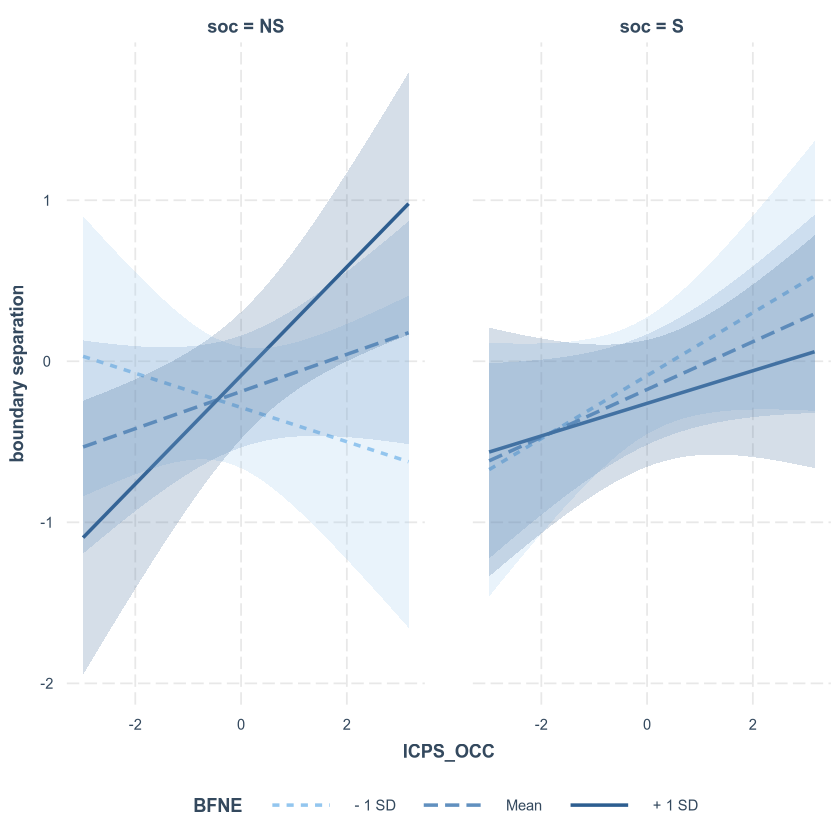

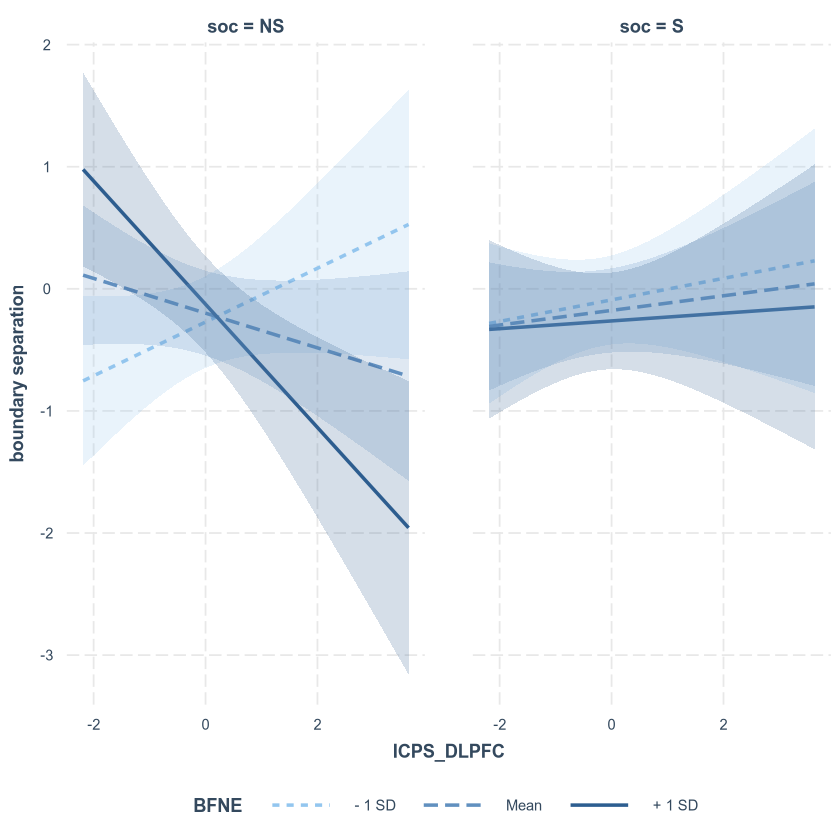

In [13]:
model <- lmer(a_diff ~ ICPS_early_DLPFC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + 	ICPS_early_MOTOR_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_OCC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
 data = tf_data)
# print(summary(model))

interact_plot(model,
              pred = "ICPS_early_OCC_diff_collapsed",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "boundary separation",
              x.label= "ICPS_OCC",
              legend.main = "BFNE"
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

interact_plot(model,
              pred = "ICPS_early_DLPFC_diff_collapsed",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "boundary separation",
              x.label= "ICPS_DLPFC",
              legend.main = "BFNE"
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

# Behavioral post-error adjustments measures predicted by ICPS

## Load data

In [3]:
rm(list = ls())
session = "s1_r1"
analysis_path = "/home/data/NDClab/analyses/thrive-theta-ddm/"
source(sprintf("%s/code/statistics/lmer_export_apa.R", analysis_path))
source(sprintf("%s/code/statistics/find_newest_file.R", analysis_path))
pic_path <- "/Users/fzaki001/thrive-theta-ddm/results/figures/ms"
# tf_data <- read.csv("/Users/fzaki001/IDENTIFIABLE/tf_data_collapsed_merged.csv")
tf_data <- read.csv(find_newest_file(sprintf("%s/derivatives/csv/%s/thrive*long*.csv", analysis_path, session)))
table_output_path = sprintf("%s/derivatives/statistics/full_sample/bfne/", analysis_path)
if (!dir.exists(table_output_path)) {
  dir.create(table_output_path, recursive = TRUE)
}
# it doesnt matter 0 or 1 because the models below use difference scores; because of that we need to get rid of duplicates (diff scores are the same for acc=0 and acc=1)
id_cols <- c('sub', 'age_m', 'sex', 'acc', 'soc', 'dp_inperson', 'first_soc')
data_cols <- c(
    'pea',
   'peri_rt',
   'pes',
   'ICPS_early_DLPFC_diff_collapsed',
   'ICPS_early_MOTOR_diff_collapsed',
   'ICPS_early_OCC_diff_collapsed',
   'bfne_b_scrdTotal_s1_r1_e1'
  )
tf_data <- tf_data[, c(id_cols, data_cols)]
tf_data <- tf_data %>%
  filter(!if_all(c(data_cols), is.na))
tf_data <- subset(tf_data, tf_data$acc == 1)

tf_data$sub <- as.factor(tf_data$sub)
tf_data$soc <- as.factor(tf_data$soc)
tf_data$sex <- as.factor(tf_data$sex)
tf_data$acc <- as.factor(tf_data$acc)
tf_data$first_soc <- as.factor(tf_data$first_soc)
# tf_data$task_num <- as.factor(tf_data$task_num)
tf_data$dp_inperson <- as.factor(tf_data$dp_inperson)

tf_data[c("age_m", data_cols)] <- as.data.frame(scale(tf_data[c("age_m", data_cols)]))

tf_data$soc <- revalue(tf_data$soc, c("0" = "NS", "1" = "S"))
tf_data$sex <- revalue(tf_data$sex, c("1" = "M", "2" = "F"))
# tf_data$acc <- revalue(tf_data$acc, c("0" = "Error", "1" = "Correct"))

# contrasts(tf_data$acc) <- rev(contr.sum(2))
contrasts(tf_data$sex) <- rev(contr.sum(2))
contrasts(tf_data$soc) <- rev(contr.sum(2))
contrasts(tf_data$first_soc) <- rev(contr.sum(2))
# contrasts(tf_data$task_num) <- rev(contr.sum(2))
contrasts(tf_data$dp_inperson) <- rev(contr.sum(2))

[1] "The newest file is: /home/data/NDClab/analyses/thrive-theta-ddm//derivatives/csv/s1_r1/thrive_long_s1_r1_22_02_2026_23_31_39.csv"


Warning message:
"There was 1 warning in `filter()`.
i In argument: `!if_all(c(data_cols), is.na)`.
Caused by warning:
! Using an external vector in selections was deprecated in tidyselect 1.1.0.
i Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(data_cols)

  # Now:
  data %>% select(all_of(data_cols))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>."


In [9]:
# 1. Define the dependent variables you want to iterate over
outcomes <- c(
    'pea',
    'pes',
    'peri_rt'
)

# 2. Define the static right-hand side of your model formula
predictors <- "ICPS_early_DLPFC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_MOTOR_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_OCC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub)"

# 3. Initialize an empty list to store the fitted models
models_list <- list()

# 4. Iterate through each outcome
for (outcome in outcomes) {
  # Dynamically build the formula
  f <- as.formula(paste(outcome, "~", predictors))
  
  # Fit the linear mixed-effects model
  cat(sprintf("Fitting model for %s...\n", outcome))
  model <- lmer(f, data = tf_data)
  print(summary(model))
  
  # Store the model in the list using the outcome name as the key
  models_list[[outcome]] <- model
  
  # Automatically export the APA table
  label <- paste0(outcome, "_bfne")
  lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label), print_formula=TRUE, formula=f)
}

Fitting model for pea...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1112

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0585 -0.5949  0.0277  0.5840  2.5482 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.09295  0.3049  
 Residual             0.83043  0.9113  
Number of obs: 367, groups:  sub, 213

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.091445
ICPS_early_DLPFC_diff_collapsed                                       -0.028793
soc1                                                                  -0.029996
age_m                                                                  0.150693
bfne_b_scrdTotal_s1_r1_e1                                              0.064967
ICPS_early_MOTOR_diff_collapsed                    


Correlation matrix not shown by default, as p = 34 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Fitting model for pes...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1099.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.74146 -0.55253  0.02278  0.59053  2.62554 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.2144   0.4631  
 Residual             0.6933   0.8327  
Number of obs: 367, groups:  sub, 214

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.056000
ICPS_early_DLPFC_diff_collapsed                                       -0.162889
soc1                                                                  -0.034548
age_m                                                                  0.056441
bfne_b_scrdTotal_s1_r1_e1                                              0.041121
ICPS_early_MOTOR_diff_collapsed        


Correlation matrix not shown by default, as p = 34 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Fitting model for peri_rt...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1121.1

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.96030 -0.55445  0.00756  0.53085  2.66239 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.07209  0.2685  
 Residual             0.88383  0.9401  
Number of obs: 366, groups:  sub, 212

Fixed effects:
                                                                       Estimate
(Intercept)                                                           2.409e-02
ICPS_early_DLPFC_diff_collapsed                                       8.209e-02
soc1                                                                  8.982e-02
age_m                                                                 9.418e-03
bfne_b_scrdTotal_s1_r1_e1                                             1.707e-02
ICPS_early_MOTOR_diff_collapsed    


Correlation matrix not shown by default, as p = 34 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
pea ~ ICPS_early_DLPFC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 +  
    ICPS_early_MOTOR_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 +  
    ICPS_early_OCC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1112

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0585 -0.5949  0.0277  0.5840  2.5482 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.09295  0.3049  
 Residual             0.83043  0.9113  
Number of obs: 367, groups:  sub, 213

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.091445
ICPS_early_DLPFC_diff_collapsed                                       -0.028793
soc1                                 


Correlation matrix not shown by default, as p = 34 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it




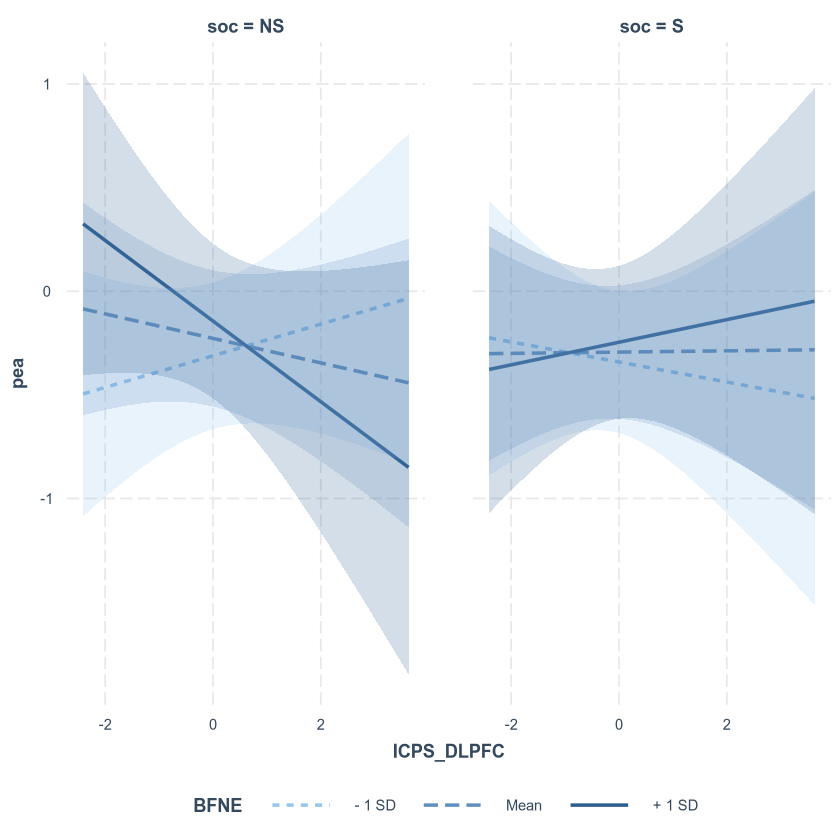

In [42]:
model <- lmer(pea ~ ICPS_early_DLPFC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + 	ICPS_early_MOTOR_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_OCC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
 data = tf_data)
print(summary(model))

interact_plot(model,
              pred = "ICPS_early_DLPFC_diff_collapsed",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "pea",
              x.label= "ICPS_DLPFC",
              legend.main = "BFNE"
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

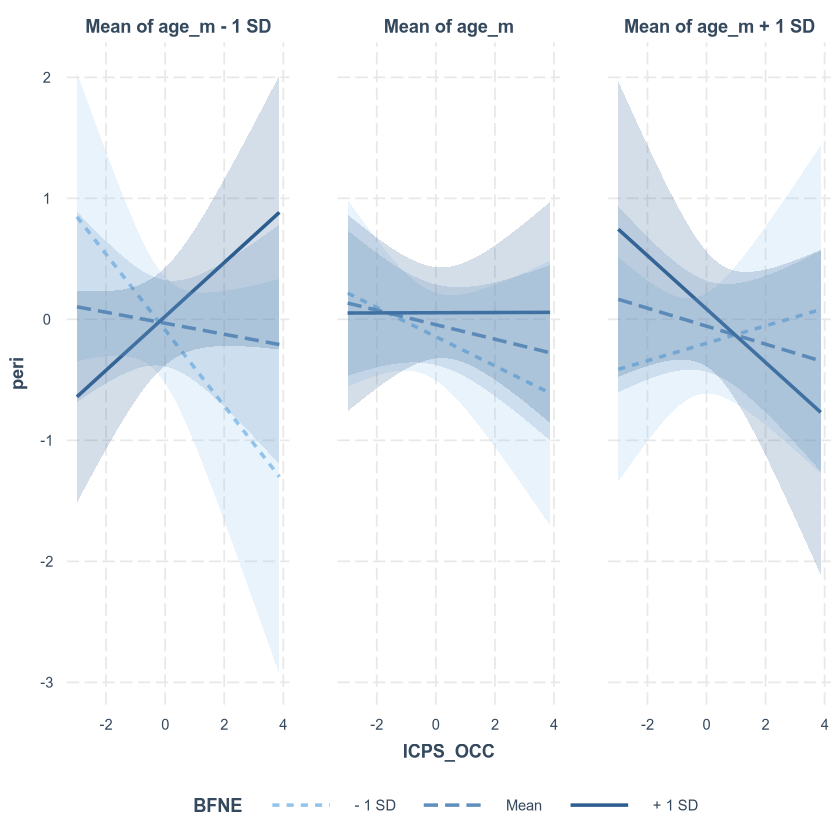

In [6]:
model <- lmer(peri_rt ~ ICPS_early_DLPFC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + 	ICPS_early_MOTOR_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_OCC_diff_collapsed * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
 data = tf_data)
# print(summary(model))

# interact_plot(model,
#               pred = "ICPS_early_MOTOR_diff_collapsed",
#               modx="bfne_b_scrdTotal_s1_r1_e1",
#               # mod2="soc",
#               interval = 1,
#               dodge.width = 0.2,
#               y.label = "peri",
#               x.label= "ICPS_MOTOR",
#               legend.main = "BFNE"
#               # x.label = "BFNE",
#              ) + theme(legend.position = "bottom")

interact_plot(model,
              pred = "ICPS_early_OCC_diff_collapsed",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="age_m",
              interval = 1,
              dodge.width = 0.2,
              y.label = "peri",
              x.label= "ICPS_OCC",
              legend.main = "BFNE"
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

# ERN predicted by acc * soc * age

## Load data

In [10]:
rm(list = ls())
session = "s1_r1"
analysis_path = "/home/data/NDClab/analyses/thrive-theta-ddm/"
source(sprintf("%s/code/statistics/lmer_export_apa.R", analysis_path))
source(sprintf("%s/code/statistics/find_newest_file.R", analysis_path))
pic_path <- "/Users/fzaki001/thrive-theta-ddm/results/figures/ms"
# tf_data <- read.csv("/Users/fzaki001/IDENTIFIABLE/tf_data_collapsed_merged.csv")
tf_data <- read.csv(find_newest_file(sprintf("%s/derivatives/csv/%s/thrive*long*.csv", analysis_path, session)))
table_output_path = sprintf("%s/derivatives/statistics/full_sample/bfne/", analysis_path)
if (!dir.exists(table_output_path)) {
  dir.create(table_output_path, recursive = TRUE)
}
id_cols <- c('sub', 'age_m', 'sex', 'acc', 'soc', 'dp_inperson', 'first_soc')
data_cols <- c(
    'ERN',
    'ERN_laplacian',
    'bfne_b_scrdTotal_s1_r1_e1'
)
tf_data <- tf_data[, c(id_cols, data_cols)]
tf_data <- tf_data %>%
  filter(!if_all(c(data_cols), is.na))

tf_data$soc <- as.factor(tf_data$soc)
tf_data$sub <- as.factor(tf_data$sub)
tf_data$sex <- as.factor(tf_data$sex)
tf_data$acc <- as.factor(tf_data$acc)
tf_data$first_soc <- as.factor(tf_data$first_soc)
# tf_data$task_num <- as.factor(tf_data$task_num)
tf_data$dp_inperson <- as.factor(tf_data$dp_inperson)

tf_data[c("age_m", data_cols)] <- as.data.frame(scale(tf_data[c("age_m", data_cols)]))

tf_data$soc <- revalue(tf_data$soc, c("0" = "NS", "1" = "S"))
tf_data$sex <- revalue(tf_data$sex, c("1" = "M", "2" = "F"))
tf_data$acc <- revalue(tf_data$acc, c("0" = "Error", "1" = "Correct"))

contrasts(tf_data$soc) <- rev(contr.sum(2))
contrasts(tf_data$acc) <- rev(contr.sum(2))
contrasts(tf_data$first_soc) <- rev(contr.sum(2))
contrasts(tf_data$sex) <- rev(contr.sum(2))
# contrasts(tf_data$task_num) <- rev(contr.sum(2))
contrasts(tf_data$dp_inperson) <- rev(contr.sum(2))

[1] "The newest file is: /home/data/NDClab/analyses/thrive-theta-ddm//derivatives/csv/s1_r1/thrive_long_s1_r1_22_02_2026_23_31_39.csv"


In [11]:
# 1. Define the dependent variables you want to iterate over
outcomes <- c(
    'ERN',
    'ERN_laplacian'
)

# 2. Define the static right-hand side of your model formula
predictors <- "acc * soc * age_m * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub)"

# 3. Initialize an empty list to store the fitted models
models_list <- list()

# 4. Iterate through each outcome
for (outcome in outcomes) {
  # Dynamically build the formula
  f <- as.formula(paste(outcome, "~", predictors))
  
  # Fit the linear mixed-effects model
  cat(sprintf("Fitting model for %s...\n", outcome))
  model <- lmer(f, data = tf_data)
  print(summary(model))
  
  # Store the model in the list using the outcome name as the key
  models_list[[outcome]] <- model
  
  # Automatically export the APA table
  label <- paste0(outcome, "_bfne")
  lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label), print_formula=TRUE, formula=f)
}

Fitting model for ERN...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1907.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.1201 -0.5645  0.0028  0.5779  3.4271 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.3994   0.6320  
 Residual             0.3190   0.5648  
Number of obs: 847, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                               -1.712e-02  6.689e-02  2.238e+02
acc1                                       4.830e-01  1.949e-02  6.091e+02
soc1                                      -1.442e-04  1.997e-02  6.302e+02
age_m                                     -1.638e-01  4.598e-02  2.241e+02
bfne_b_scrdTotal_s1_r1_e1                 -2.742e-02  4.808e-02  2.245e+02
sex1                                      -1.392e-01  4.888e-02  2.249e+02
dp_i


Correlation matrix not shown by default, as p = 18 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



Fitting model for ERN_laplacian...
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: tf_data

REML criterion at convergence: 1842.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.8670 -0.5384  0.0132  0.5482  2.8516 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.5339   0.7307  
 Residual             0.2692   0.5188  
Number of obs: 841, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.045491   0.074696 221.721081
acc1                                        0.416219   0.018018 601.013348
soc1                                       -0.023554   0.018494 615.851391
age_m                                      -0.011306   0.051358 222.425284
bfne_b_scrdTotal_s1_r1_e1                  -0.005473   0.053658 222.079289
sex1                                       -0.161822   0.054553 222.5


Correlation matrix not shown by default, as p = 18 > 12.
Use print(summary(model), correlation=TRUE)  or
    vcov(summary(model))        if you need it


Computing profile confidence intervals ...



In [12]:
source(sprintf("%s/code/statistics/combine_docs.R", analysis_path))
combine_docs(table_output_path)